In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import json
import datetime
import os
import time
import pytz
import matplotlib.pyplot as plt
import scipy

In [7]:
symbols = ['LLY']

7016     4.539150
6538     4.476077
7699     4.320583
5953     4.316476
12043    4.275100
           ...   
2730    -4.694839
10938   -4.711208
7674    -4.720988
6658    -4.789765
12055   -4.870750
Name: log_ret, Length: 13321, dtype: float64
[-3.95220072 -3.56504545 -3.56410299 ...  3.21137601  3.26629935
  3.30843415]
3.537214265472076e-148


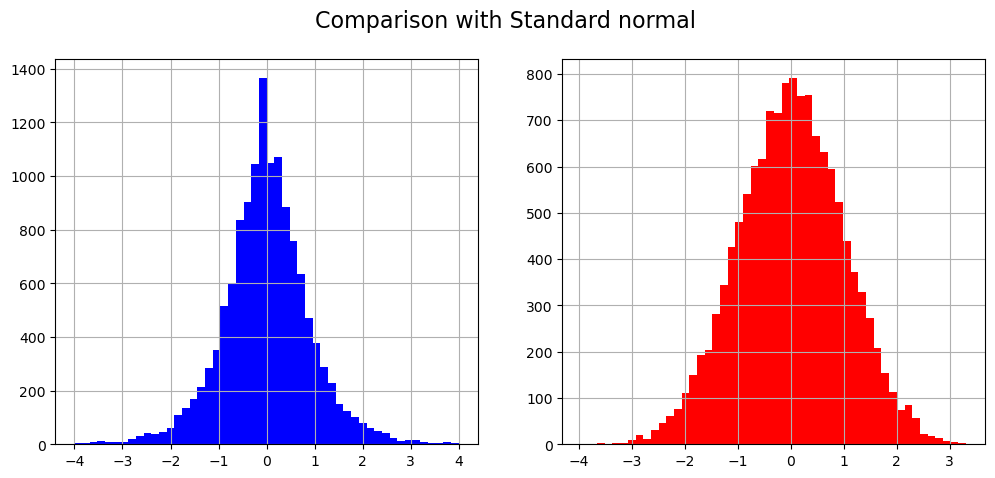

In [82]:
for symbol in symbols:
    stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
    stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
    stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
    stockprices['close_prev'] = stockprices['Close'].shift(1)
    stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
    mean = stockprices['log_ret'].mean()
    std = stockprices['log_ret'].std()
    logret_normalised = (stockprices['log_ret'].dropna() - mean)/std
    logret_filtered = logret_normalised[(logret_normalised<5)&(logret_normalised>(-5))]
    gaussian = np.random.standard_normal(len(logret_filtered))
    #plt.hist(stockprices['log_ret'], bins=100)
    #plt.show()
    print(logret_filtered.sort_values(ascending=False))
    gaussian.sort()
    print(gaussian)
    res = scipy.stats.normaltest(logret_filtered)
    print(res.pvalue)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Comparison with Standard normal', fontsize=16)
    ax1.hist(logret_filtered, bins=50, color='b', range=(-4,4))
    ax2.hist(gaussian, bins=50, color='r')
    # ax1.set_title('First Plot')
    # ax1.set_xlabel('x-axis')
    # ax1.set_ylabel('y-axis')
    ax1.grid(True) # Add a grid for better readability
    ax2.grid(True) # Add a grid
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




In [70]:
stockprices['close_prev'] = stockprices['Close'].shift(1)
stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
stockprices['log_ret'].sort_values()

7122    -0.345002
3885    -0.271934
5585    -0.137586
9175    -0.131799
833     -0.128019
           ...   
9177     0.134089
12906    0.138628
12115    0.145655
7094     0.153049
0             NaN
Name: log_ret, Length: 13354, dtype: float64

In [76]:
stockprices['log_ret'].mean()

0.00050348085834978

In [80]:
logret_normalised.mean()

-1.9156398178209846e-17

In [74]:
np.sqrt(stockprices['log_ret'].var())

0.017293958192597124

In [33]:
stockprices_1min = yf.download('LLY', period='8d', interval='1m')

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_22473/3317287755.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockprices_1min = yf.download('LLY', period='8d', interval='1m')
[*********************100%***********************]  1 of 1 completed


In [57]:
stockprices_1min.iloc[2630:2670]

Price,Close,High,Low,Open,Volume,close_prev,log_ret
Ticker,LLY,LLY,LLY,LLY,LLY,,
Datetime,,,,,,,
2025-06-20 19:50:00+00:00,765.515015,765.635010,764.000000,764.700012,17356,764.997498,0.000676
2025-06-20 19:51:00+00:00,765.831970,766.000000,765.429993,765.429993,12596,765.515015,0.000414
2025-06-20 19:52:00+00:00,765.825012,766.200012,765.619995,765.919983,10698,765.831970,-0.000009
2025-06-20 19:53:00+00:00,766.284973,766.309998,765.765015,765.765015,9024,765.825012,0.000600
2025-06-20 19:54:00+00:00,766.380005,767.489990,766.304993,766.440002,29719,766.284973,0.000124
2025-06-20 19:55:00+00:00,766.200012,766.966492,765.900085,766.544983,25926,766.380005,-0.000235
2025-06-20 19:56:00+00:00,766.359985,766.729980,766.000000,766.200012,16060,766.200012,0.000209
2025-06-20 19:57:00+00:00,764.929993,766.369995,764.840027,766.349976,21442,766.359985,-0.001868


Datetime
2025-06-12 13:35:00+00:00    4.587499
2025-06-20 14:01:00+00:00    4.535393
2025-06-13 13:41:00+00:00    3.776692
2025-06-12 13:30:00+00:00    3.642673
2025-06-16 13:38:00+00:00    3.352819
                               ...   
2025-06-17 13:53:00+00:00   -4.222655
2025-06-16 13:33:00+00:00   -4.291255
2025-06-20 13:54:00+00:00   -4.321614
2025-06-23 19:51:00+00:00   -4.360973
2025-06-18 13:33:00+00:00   -4.403646
Name: log_ret, Length: 2997, dtype: float64
[-4.11363036 -3.27492262 -3.25868547 ...  3.45664452  3.59947353
  3.89040097]
3.8158551387238194e-72


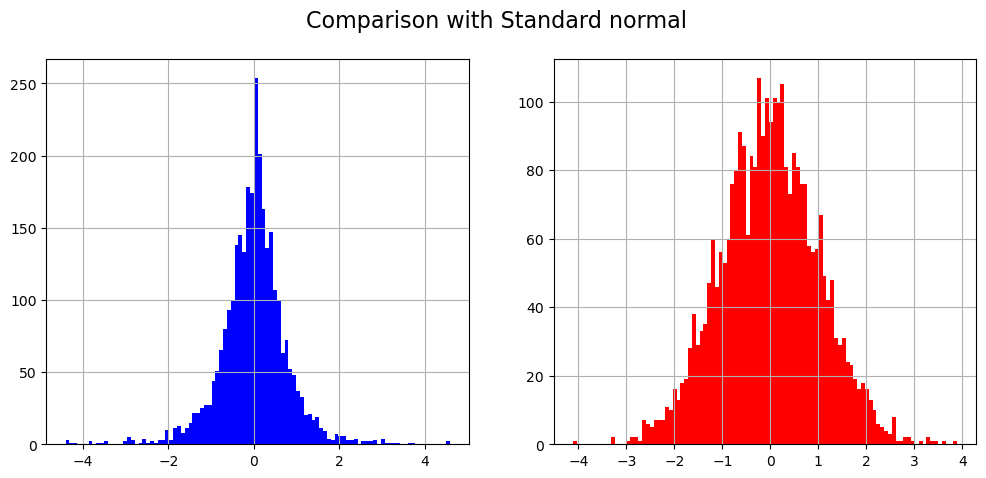

In [83]:
stockprices_1min['close_prev'] = stockprices_1min['Close']['LLY'].shift(1)
stockprices_1min['log_ret'] = np.log(stockprices_1min['Close']['LLY']/stockprices_1min['close_prev'])
mean = stockprices_1min['log_ret'].mean()
std = stockprices_1min['log_ret'].std()
logret_normalised = (stockprices_1min['log_ret'].dropna() - mean)/std
logret_filtered = logret_normalised[(logret_normalised<5)&(logret_normalised>(-5))]
gaussian = np.random.standard_normal(len(logret_filtered))
#plt.hist(stockprices['log_ret'], bins=100)
#plt.show()
print(logret_filtered.sort_values(ascending=False))
gaussian.sort()
print(gaussian)
res = scipy.stats.normaltest(logret_filtered)
print(res.pvalue)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparison with Standard normal', fontsize=16)
ax1.hist(logret_filtered, bins=100, color='b')
ax2.hist(gaussian, bins=100, color='r')
# ax1.set_title('First Plot')
# ax1.set_xlabel('x-axis')
# ax1.set_ylabel('y-axis')
ax1.grid(True) # Add a grid for better readability
ax2.grid(True) # Add a grid
#plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [45]:
stockprices_1min['close_prev'] = stockprices_1min['Close']['LLY'].shift(1)
stockprices_1min['log_ret'] = np.log(stockprices_1min['Close']['LLY']/stockprices_1min['close_prev'])
stockprices_1min

Price,Close,High,Low,Open,Volume,close_prev,log_ret
Ticker,LLY,LLY,LLY,LLY,LLY,,
Datetime,,,,,,,
2025-06-11 13:30:00+00:00,808.280029,809.650024,805.619995,809.650024,90613,NaN,NaN
2025-06-11 13:31:00+00:00,810.000000,810.419983,806.909973,807.840027,27834,808.280029,0.002126
2025-06-11 13:32:00+00:00,812.039978,812.520020,809.280029,809.539978,18036,810.000000,0.002515
2025-06-11 13:33:00+00:00,811.719971,813.195007,811.700012,811.700012,15176,812.039978,-0.000394
2025-06-11 13:34:00+00:00,812.239990,813.412903,811.330078,813.412903,13579,811.719971,0.000640
...,...,...,...,...,...,...,...
2025-06-23 19:55:00+00:00,769.854980,769.880005,768.330078,768.830017,18328,768.909973,0.001228
2025-06-23 19:56:00+00:00,769.434998,769.969971,769.434998,769.849976,17563,769.854980,-0.000546


In [63]:
stockprices_1min['close_prev'] = stockprices_1min['Close']['LLY'].shift(1)
stockprices_1min['log_ret'] = np.log(stockprices_1min['Close']['LLY']/stockprices_1min['close_prev'])
stockprices_1min['log_ret'].sort_values()

Datetime
2025-06-17 13:33:00+00:00   -0.013808
2025-06-20 13:32:00+00:00   -0.008824
2025-06-18 13:31:00+00:00   -0.007828
2025-06-16 13:32:00+00:00   -0.007444
2025-06-20 13:31:00+00:00   -0.007329
                               ...   
2025-06-18 13:32:00+00:00    0.008291
2025-06-17 13:37:00+00:00    0.008577
2025-06-23 13:31:00+00:00    0.009568
2025-06-23 13:30:00+00:00    0.016341
2025-06-11 13:30:00+00:00         NaN
Name: log_ret, Length: 3015, dtype: float64

In [66]:
stockprices_1min['log_ret'].mean()

-1.5890808721993976e-05

In [77]:
np.sqrt(stockprices_1min['log_ret'].var())

0.0010700144562426441